1. Screen capture
2. Generate dataset and load it
3. fit the model using SVC and calculate accuracy
4. Prediction of image drawn in paint

# Screen capture

In [1]:
def one_time():
    import pyscreenshot as ImageGrab
    import time
    images_folder = "capture_images/9/"
    for i in range(0,50):
        time.sleep(8)
        im=ImageGrab.grab(bbox=(60,260,400,550)) #x1,y1,x2,y2
        print("Images save..........",i)
        im.save(images_folder+str(i)+'.png')
        print("clear screen now and redraw again.........")

# Generate the dataset

In [2]:
import cv2
import csv
import glob

header =["label"]
for i in range(0,784):
    header.append("pixel"+str(i))
with open ('dataset.csv','a') as f:
    writer =csv.writer(f)
    writer.writerow(header)

for label in range(10):
    dirList =glob.glob("capture_images/"+str(label)+"/*.png")

    for img_path in dirList:
         im= cv2.imread(img_path)
         im_gray = cv2.cvtColor(im,cv2.COLOR_BGR2GRAY)
         im_gray = cv2.GaussianBlur(im_gray,(15,15),0)
         roi= cv2.resize(im_gray,(28,28),interpolation= cv2.INTER_AREA)

         data=[]
         data.append(label)
         rows,cols= roi.shape

         for i in range(rows):
             for j in range(cols):
                 k= roi[i,j]
                 if k>50:
                     k=1
                 else:
                     k=0
                 data.append(k)
         with open ('dataset.csv','a') as f:
             writer =csv.writer(f)
             writer.writerow(data)              


# Load the dataset

In [3]:
import pandas as pd 
from sklearn.utils import shuffle
data =pd.read_csv('dataset.csv')
data=shuffle(data)
data

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
156,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
350,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
394,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
255,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
130,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
207,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
220,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
414,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Separation of dependent and Independent variable

In [4]:
X =data.drop(["label"],axis=1)
Y=data["label"]


# Preview of one image using matplotlib

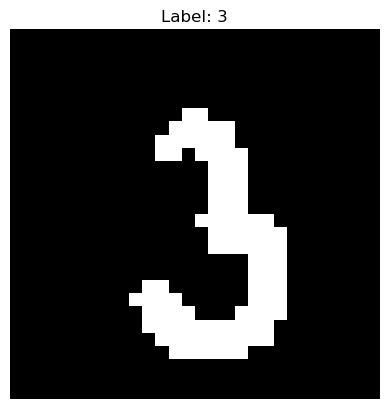

In [5]:
import matplotlib.pyplot as plt
import numpy as np


idx = X.index[0]

img = X.loc[idx].to_numpy().astype(float).reshape(28, 28)

plt.imshow(img, cmap="gray")
plt.title("Label: " + str(Y.loc[idx]))
plt.axis("off")
plt.show()

# Train-test split

In [6]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(train_x.shape, train_y.shape)


(400, 784) (400,)


# Fit the model using svc and calculate accuracy

In [7]:
from sklearn.svm import SVC
from sklearn import metrics
import joblib

model = SVC(kernel="linear")
model.fit(train_x, train_y)
pred = model.predict(test_x)
print("Accuracy:", metrics.accuracy_score(test_y, pred))
joblib.dump(model, "digit_recognizer.pkl")

Accuracy: 0.89


['digit_recognizer.pkl']

# Prediction of image drawn in the paint

In [25]:
import joblib
import cv2
import numpy as np
import pyscreenshot as ImageGrab

model = joblib.load("model/digit_recognizer")

while True:

   
    img = ImageGrab.grab(bbox=(60, 260, 400, 550))
    im = np.array(img)

    
    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (15, 15), 0)
    _, th = cv2.threshold(blur, 100, 255, cv2.THRESH_BINARY)

    roi = cv2.resize(th, (28, 28))

   
    X = []
    rows, cols = roi.shape

    for i in range(rows):
        for j in range(cols):
            if roi[i, j] > 100:
                X.append(1)
            else:
                X.append(0)

   
    predictions = model.predict([X])
    print("Prediction:", predictions[0])

    
    cv2.putText(im,
                "Prediction: " + str(predictions[0]),
                (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (0, 255, 0),
                2)

    cv2.startWindowThread()
    cv2.namedWindow("Result")
    cv2.imshow("Result", im)

   
    if cv2.waitKey(1000) == 13:
        break

cv2.destroyAllWindows()

C:\Users\Muskan Rawat\anaconda3\juptyer\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Prediction: 9


C:\Users\Muskan Rawat\anaconda3\juptyer\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Prediction: 9


C:\Users\Muskan Rawat\anaconda3\juptyer\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


...

Prediction: 0


C:\Users\Muskan Rawat\anaconda3\juptyer\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Prediction: 0


C:\Users\Muskan Rawat\anaconda3\juptyer\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Prediction: 0
